In [34]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit, prange
import os
import time
import dask.array as da
from dask import delayed
from dask.distributed import Client

In [35]:
import multiprocessing
multiprocessing.cpu_count()

16

In [36]:
# n_workers=1 + threads: nessun overhead IPC, memoria condivisa.
# nogil=True in Numba rilascia il GIL → i 16 thread lavorano davvero in parallelo.
client = Client(n_workers=1, threads_per_worker=16)
client


/home/ubuntu/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41899 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41899/status,
Dashboard: http://127.0.0.1:41899/status,Workers: 1
Total threads: 16,Total memory: 3.82 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38257,Workers: 0
Dashboard: http://127.0.0.1:41899/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39741,Total threads: 16
Dashboard: http://127.0.0.1:37619/status,Memory: 3.82 GiB
Nanny: tcp://127.0.0.1:35377,


In [37]:
@jit(nopython=True, fastmath=True,cache=True,nogil=True)
def kolchinsky(T, Y, sigma2:float):  #nats units

    T = T.astype(np.float32)           #a matrix of shape (n_samples, n_features); features are neurons
    sigma2 = np.float32(sigma2)
    
    n_samples, n_features = T.shape   
    
    norms2 = np.zeros(n_samples, dtype=np.float32) #initializing squares of euclidean norms of rows of T (i need only squares); array of scalars
    for i in range(n_samples):                     #for each row
        norm = np.float32(0.0)                     #initializing a scalar
        Ti = T[i]                                  #the i-th row of T: a vector of length n_features; faster to access it once than multiple times in inner loop
        for k in range(n_features):                #for each column (neuron)
            val = Ti[k]                            #the value of the k-th feature of the i-th sample; accessing it once 
            norm += val * val                      #norms2 of the row as temporary variable
        norms2[i] = norm                           #moving from temporary variable to array position
    
    unique_y = np.unique(Y)                        #sorted array (usually lenght 10); this reguards only Y, not T
    class_indices = []                             #list of unique_y arrays (10 arrays)
    for cls in unique_y:                           #for each label (class)
        indices = np.where(Y == cls)[0]            #the output is a tuple of arrays (one array), I need only the 0-th; cls==Y is boll, np.where gives the indices of True values
        class_indices.append(indices)              
    
    def compute_H(sigma2):                      #I(T;X)=H(T) - H(T|X)(=0); kolchinsky estimates only upper bound
        denom_up = np.float32(2.0)*sigma2       #denominator of exp; precomputing it for efficiency
        denom_low = np.float32(8.0)*sigma2
        log_sum_up = np.float32(0.0)            #initializing sum of the log (outer sum over i)
        log_sum_low = np.float32(0.0)
        
        for i in range(n_samples):              #for each row of T (i-th sample); outer sum over i
            row_sum_up = np.float32(0.0)        #the inner sum; the sum is over j, so each i has its own row_sum
            row_sum_low = np.float32(0.0)
            norm2_i = norms2[i]                 #norms2 is an array of scalars
            Ti = T[i]                           #all neurons of sample i; I will need later for the double product
            
            for j in range(n_samples):          #for the i-th sample, I consider all j-th samples; inner sum over j
                if i == j:                           #self-distance
                    row_sum_up += np.float32(1.0)    #distance is zero, exp(0)=1
                    row_sum_low += np.float32(1.0)
                else:                           #||a-b||^2 = a^2 + b^2 -2*a*b due to the development of (a-b)(a-b)
                    dot = np.float32(0.0)       #so I compute the double product; here initializing for pair i,j
                    Tj = T[j]                   #the j-th row of T;
                    for k in range(n_features): #for each neuron
                        dot += Ti[k] * Tj[k]    #scalar product
                    
                    distance = norm2_i + norms2[j] - np.float32(2.0) * dot #||a-b||^2=a^2+b^2-2*a*b due to the development of (a-b)(a-b)
                    row_sum_up += np.exp(-distance / denom_up)             #inner sum (over j)
                    row_sum_low += np.exp(-distance / denom_low)
            
            log_sum_up += np.log(row_sum_up / n_samples + np.float32(1e-12))     #outer sum (ever i: sum of the logs)
            log_sum_low += np.log(row_sum_low / n_samples + np.float32(1e-12))

        return -log_sum_up / n_samples, -log_sum_low / n_samples
    
    def compute_H_givenY(sigma2):                              #only the second term of the formula, the first is calculated in "compute_H" bcs it is the same
        denom_up = np.float32(2.0) * np.float32(1.0) * sigma2
        denom_low = np.float32(2.0) * np.float32(4.0) * sigma2
        total_up = np.float32(0.0)                  #inizializing outer sum (we have triple sum)
        total_low = np.float32(0.0)

        for class_idx in class_indices:             #for each label, array of corresponding indices
            n_class = len(class_idx)                
            if n_class > 0:                         #almost always true; if at least one sample of the class is present                
                class_sum_up = np.float32(0.0)      #initializing mid sum (we have triple sum)
                class_sum_low = np.float32(0.0)
                for i_idx in range(n_class):        #0,1,2,...,label_max; here we fix the label
                    i = class_idx[i_idx]            #if i_idx=0, it is array of indices of samples with label 0
                    row_sum_up = np.float32(0.0)    #inner sum
                    row_sum_low = np.float32(0.0)
                    norm2_i = norms2[i]              #accessing once and storing temporary; a scalar
                    Ti = T[i]                        #same, but a list      
                    for j_idx in range(n_class):     #inner sum over j (rows), 
                        j = class_idx[j_idx]
                        if i == j:                   #distance is zero, exp(0)=1
                            row_sum_up += np.float32(1.0)
                            row_sum_low += np.float32(1.0)
                        else:                        #pair-wise distance ||a-b||^2 = a^2 + b^2 -2*a*b
                            dot = np.float32(0.0)    #initializing double product
                            Tj = T[j]
                            for k in range(n_features): #computing double product
                                dot += Ti[k] * Tj[k]
                            distance = norm2_i + norms2[j] - np.float32(2.0) * dot
                            row_sum_up += np.exp(-distance / denom_up)                   #updating inner sum (over j)
                            row_sum_low += np.exp(-distance / denom_low)
                    class_sum_up += np.log(row_sum_up / n_class + np.float32(1e-12))     #updating mid sum (over i)
                    class_sum_low += np.log(row_sum_low / n_class + np.float32(1e-12))   
                total_up += -class_sum_up                                                #updating numerator outer sum (over classes)
                total_low += -class_sum_low
        return total_up / n_samples, total_low / n_samples                               #returning with denominator

    
    H_X_up, H_X_low = compute_H(sigma2)
    H_X_givenY_up, H_X_givenY_low = compute_H_givenY(sigma2)
    
    I_XY_up = H_X_up - H_X_givenY_up
    I_XY_low = H_X_low - H_X_givenY_low
    
    return (np.float32(H_X_up), np.float32(I_XY_up), np.float32(H_X_low), np.float32(I_XY_low))

In [38]:
class kolchinsky_with_sampling:                        #wrapper of kolchinsky, but in bits and with sampling
    def __init__(self, sigma2:float, sample_size:int):
        self.sigma2 = sigma2
        self.sample_size = sample_size
        
    def compute_bounds(self, T, Y):
        n_samples = T.shape[0]                                         #total samples before sampling
        
        unique_y = np.unique(Y)                                        #unique labels sorted
        samples_per_class = self.sample_size // len(unique_y)          #
        
        indices = []
        for cls in unique_y:
            cls_idx = np.where(Y == cls)[0]
            n_take = min(len(cls_idx), samples_per_class)
            chosen = np.random.choice(cls_idx, n_take, replace=False)
            indices.extend(chosen)
        
        if len(indices) > self.sample_size:
            indices = indices[:self.sample_size]
        elif len(indices) < self.sample_size:
            extra = np.random.choice(n_samples, self.sample_size - len(indices), replace=False)
            indices.extend(extra)
        
        indices = np.array(indices, dtype=np.int64)
        if hasattr(T, 'take_rows'):
            T = T.take_rows(indices)                                   #lazy loader: fetch rows only when needed
        elif isinstance(T, da.Array):
            T = T[indices].compute()                                   #load only the sampled rows into memory
        else:
            T = T[indices]
        Y = Y[indices]
        n_samples = len(indices)
        
        H_X_up, I_XY_up, H_X_low, I_XY_low = kolchinsky(T, Y, self.sigma2)
        
        return {                                           #returns a dictionary, in bits
            'H_X_up': max(0, H_X_up / np.log(2)),            
            'I_XY_up': max(0, I_XY_up / np.log(2)),
            'H_X_low': max(0, H_X_low / np.log(2)),
            'I_XY_low': max(0, I_XY_low / np.log(2)),
            'n_samples': n_samples
        }

In [39]:
FOLDER_PATH = 'MNIST_1024-0_20-1_20-2_20-3_ReLU'

data_path = os.path.join(FOLDER_PATH, 'data.npz')
with np.load(data_path) as data:
    Y_labels = data['true_labels'].copy()

layers = {}
layer_names = []

def inspect_layer(layer_path):
    with np.load(layer_path, mmap_mode='r') as layer_data:
        n_epochs = len(layer_data.files)
        sample_key = layer_data.files[0]
        sample_shape = layer_data[sample_key].shape                      #memmap: cheap to query shape
    return n_epochs, sample_shape

for file in sorted(os.listdir(FOLDER_PATH)):
    if file == 'data.npz':
        continue
    layer_name = file.removesuffix('.npz')
    layer_names.append(layer_name)
    layer_path = os.path.join(FOLDER_PATH, file)
    
    n_epochs, (n_samples, n_features) = inspect_layer(layer_path)
    layers[layer_name] = {
        'path': layer_path,
        'n_epochs': n_epochs,
        'n_samples': n_samples,
        'n_features': n_features
    }

if not layer_names:
    raise RuntimeError(f'Nessun file di attivazioni trovato in {FOLDER_PATH}')

In [40]:
@delayed
def _load_rows(layer_path, epoch_idx, row_indices):
    with np.load(layer_path, mmap_mode='r') as layer_data:
        arr = layer_data[f'arr_{epoch_idx}']
        subset = arr[row_indices]                                      #memmap slice; loads only needed rows
        return np.asarray(subset, dtype=np.float32)

class LazyLayerEpoch:
    def __init__(self, layer_path, epoch_idx, n_samples, n_features):
        self.layer_path = layer_path
        self.epoch_idx = epoch_idx
        self.shape = (n_samples, n_features)

    def take_rows(self, row_indices):
        delayed_block = _load_rows(self.layer_path, self.epoch_idx, row_indices)
        return delayed_block.compute()

In [41]:
sigma2 = 10
sample_size = 10000
n_epochs_total = min(info['n_epochs'] for info in layers.values())
n_epochs_to_analyze = min(100, n_epochs_total)

print("=" * 70)
print(f"σ² = {sigma2}")
print(f"Batch size for MI = {sample_size}")
print(f"H(X)_max = log2({sample_size}) = {np.log2(sample_size):.2f} bits")

results = {}
for layer_name in layer_names:
    results[layer_name] = {
        'I_XT_up': [], 'I_TY_up': [],
        'I_XT_low': [], 'I_TY_low': [],
        'epochs': []
    }

# ── helper delayed ──────────────────────────────────────────────────────────
@delayed
def compute_bounds_delayed(layer_path, epoch_idx, n_samples, n_features, y_labels, sigma2, sample_size):
    """Eseguito in un thread worker: carica le righe e calcola MI."""
    T = LazyLayerEpoch(layer_path, epoch_idx, n_samples, n_features)
    Y = y_labels[:n_samples]
    _analyzer = kolchinsky_with_sampling(sigma2=sigma2, sample_size=sample_size)
    return _analyzer.compute_bounds(T, Y)

print(f"\nCalcolo MI per {n_epochs_to_analyze} epoche (Dask parallel)...\n{FOLDER_PATH}")
print("=" * 50)

# ── costruzione del grafo Dask ────────────────────────────────────────────────
# Tutti i task (epoch × layer) sono indipendenti → lanciati in parallelo
start_time = time.time()

task_keys = []
task_delayed = []
for epoch in range(n_epochs_to_analyze):
    for layer_name in layer_names:
        info = layers[layer_name]
        task_keys.append((epoch, layer_name))
        task_delayed.append(compute_bounds_delayed(
            info['path'], epoch, info['n_samples'], info['n_features'],
            Y_labels, sigma2, sample_size
        ))

# ── submit e raccolta ─────────────────────────────────────────────────────────
futures = client.compute(task_delayed)           # submit non-blocking
resolved = client.gather(futures)                # attende tutti

total_time = time.time() - start_time

# ── riorganizza i risultati ───────────────────────────────────────────────────
for (epoch, layer_name), bounds in zip(task_keys, resolved):
    results[layer_name]['I_XT_up'].append(bounds['H_X_up'])
    results[layer_name]['I_TY_up'].append(bounds['I_XY_up'])
    results[layer_name]['I_XT_low'].append(bounds['H_X_low'])
    results[layer_name]['I_TY_low'].append(bounds['I_XY_low'])
    results[layer_name]['epochs'].append(epoch)

# ordina per epoca (i future arrivano in ordine di completamento, non submission)
for layer_name in layer_names:
    order = np.argsort(results[layer_name]['epochs'])
    for key in ('I_XT_up', 'I_TY_up', 'I_XT_low', 'I_TY_low', 'epochs'):
        results[layer_name][key] = [results[layer_name][key][i] for i in order]

n_workers_actual = len(client.scheduler_info()['workers'])
print(f"TOTAL TIME: {total_time:.1f}s ({total_time/60:.1f} min)  "
      f"({n_epochs_to_analyze * len(layer_names)} task, {n_workers_actual} worker)")


σ² = 10
Batch size for MI = 10000
H(X)_max = log2(10000) = 13.29 bits

Calcolo MI per 100 epoche (Dask parallel)...
MNIST_1024-0_20-1_20-2_20-3_ReLU
TOTAL TIME: 257.8s (4.3 min)  (400 task, 1 worker)


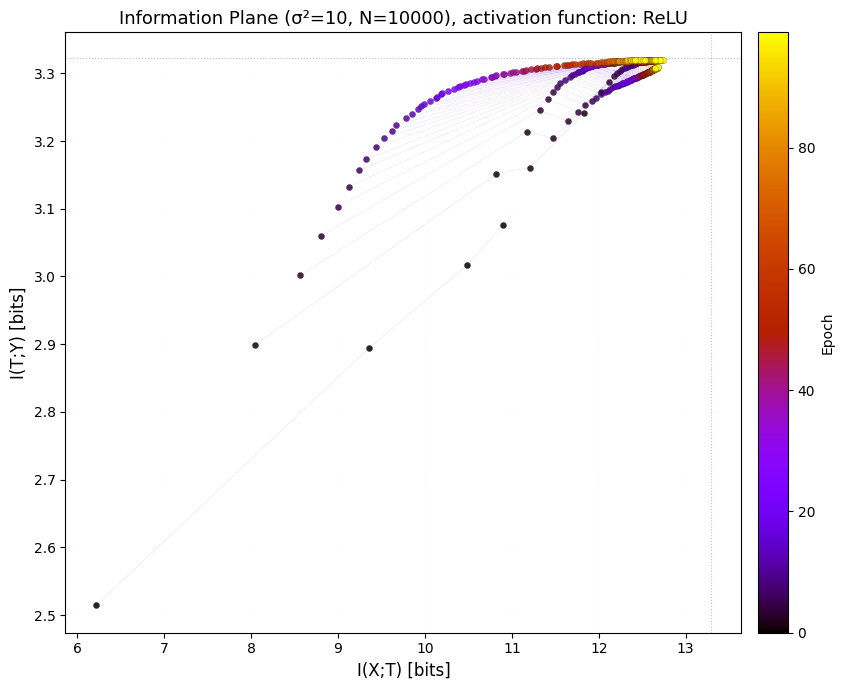

In [42]:
plt.figure(figsize=(9, 7))

colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        epoch_points_x.append(results[layer_name]['I_XT_up'][epoch])
        epoch_points_y.append(results[layer_name]['I_TY_up'][epoch])
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20, alpha=0.85, edgecolors='black',
               linewidth=0.15, marker='o',
               zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        points.append((results[layer_name]['I_XT_up'][epoch],
                      results[layer_name]['I_TY_up'][epoch]))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}), activation function: ReLU', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6.86
y_margin_min = 2.88
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min        #+2%
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)

plt.tight_layout()
plt.show()

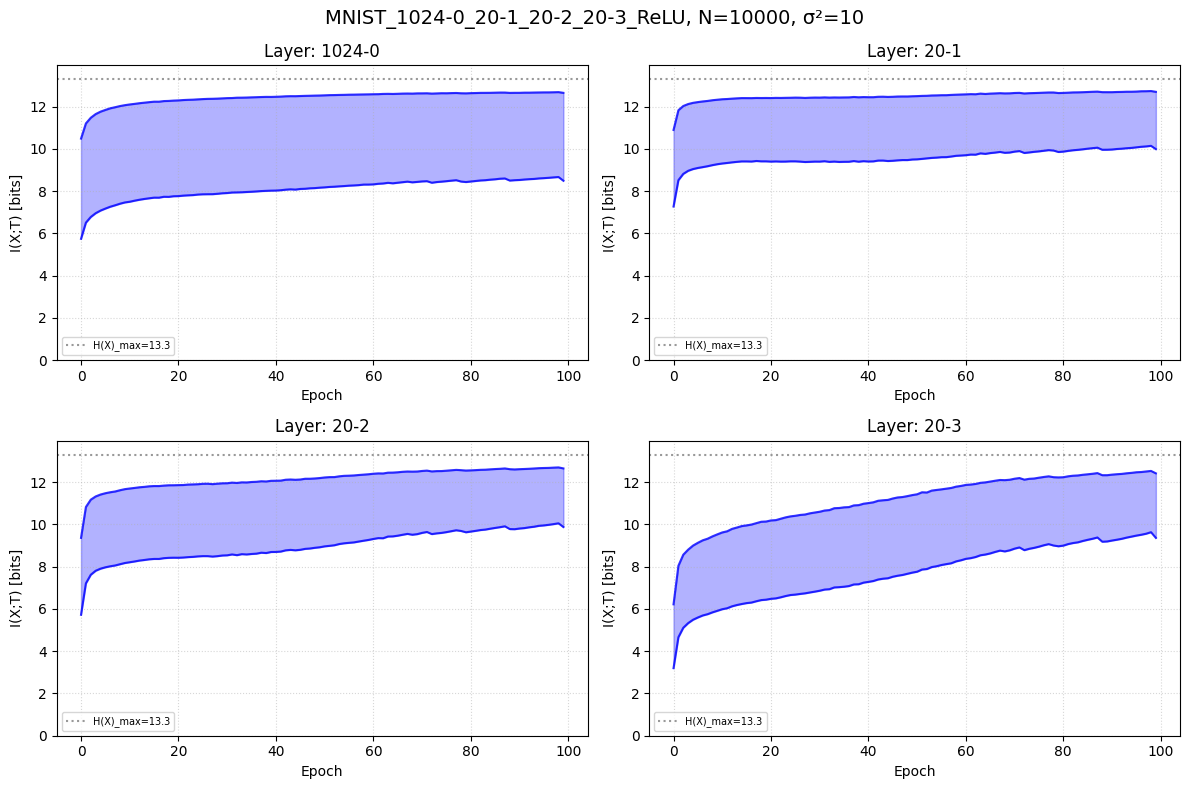

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (layer_name, ax) in enumerate(zip(layer_names, axes)):
    epochs = results[layer_name]['epochs']
    I_XT_up = results[layer_name]['I_XT_up']
    I_XT_low = results[layer_name]['I_XT_low']
    
    ax.fill_between(epochs, I_XT_low, I_XT_up, alpha=0.3, color='blue')
    
    ax.plot(epochs, I_XT_up, 'b-', linewidth=1.5, alpha=0.8)
    ax.plot(epochs, I_XT_low, 'b-', linewidth=1.5, alpha=0.8)
    
    ax.axhline(y=H_X_max, color='gray', linestyle=':',alpha=0.8, linewidth=1.5, label=f'H(X)_max={H_X_max:.1f}')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('I(X;T) [bits]', fontsize=10)
    ax.set_title(f'Layer: {layer_name}', fontsize=12)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.5, linestyle=':')
    ax.set_ylim(0, H_X_max * 1.05)

fig.suptitle(f'{FOLDER_PATH}, N={sample_size}, σ²={sigma2}', fontsize=14)
plt.tight_layout()
plt.show()

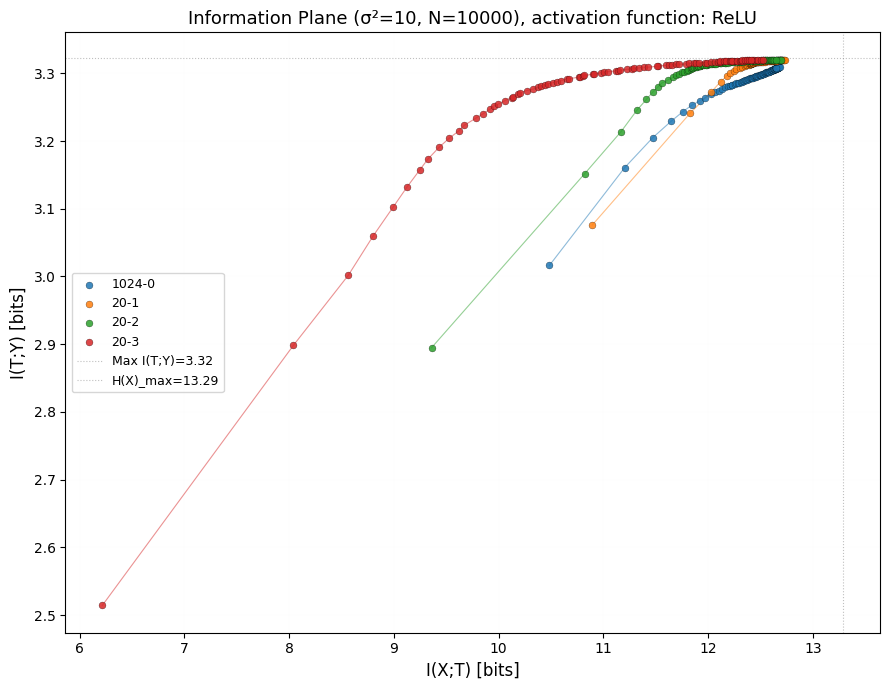

In [44]:
plt.figure(figsize=(9, 7))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, layer_name in enumerate(layer_names):
    
    color = colors[idx % len(colors)]   # ciclo colori se i layer sono molti
    
    x_vals = results[layer_name]['I_XT_up']
    y_vals = results[layer_name]['I_TY_up']
    
    # punti (una nuvola per layer)
    plt.scatter(x_vals, y_vals, s=25, alpha=0.85,
                edgecolors='black',
                linewidth=0.2, marker='o',
                color=color,label=layer_name,zorder=5)
    
    # linea temporale (collega le epoche)
    plt.plot(x_vals, y_vals,
             '-', color=color,
             alpha=0.5, linewidth=0.8, zorder=3)

# 2. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}), activation function: ReLU', fontsize=13)

# 3. Scale teoriche
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)

plt.axhline(y=max_I_TY, color='gray', linestyle=':',
            alpha=0.5, linewidth=0.8, zorder=0,
            label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':',
            alpha=0.5, linewidth=0.8, zorder=0,
            label=f'H(X)_max={H_X_max:.2f}')

plt.legend(fontsize=9)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)

plt.tight_layout()
plt.show()

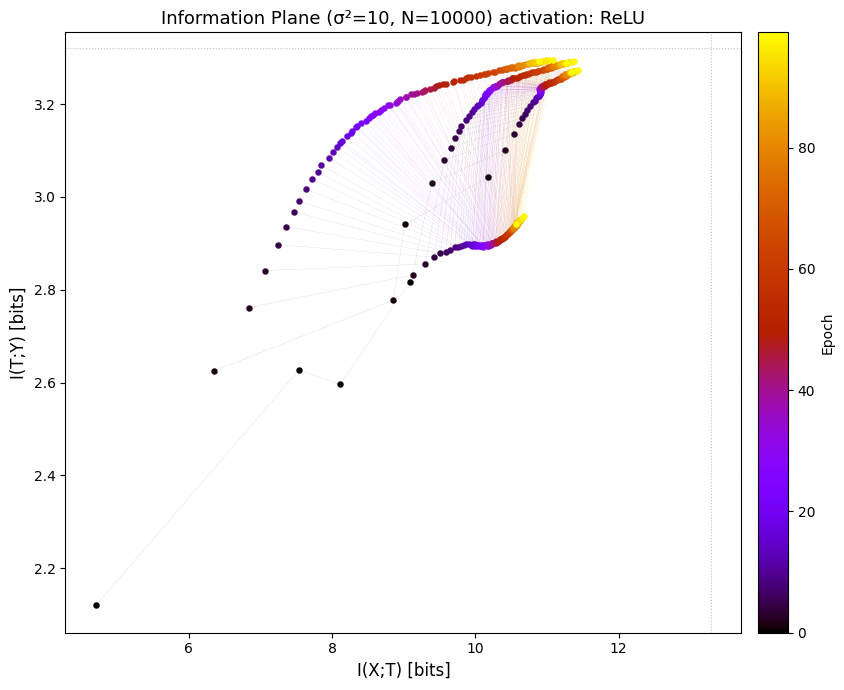

In [45]:
plt.figure(figsize=(9, 7))

# Colormap per epoche
colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

# 1. Plot dei PUNTI (media upper/lower)
for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        
        epoch_points_x.append(I_XT_mean)
        epoch_points_y.append(I_TY_mean)
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20,linewidth=0.15, marker='o', zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        points.append((I_XT_mean, I_TY_mean))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}) activation: ReLU', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6
y_margin_min = 2.7
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)
plt.tight_layout()
plt.show()

In [46]:
client.close()